### Explore Pandas

Ww will study an 'easy' cluster, Alpha Persei

This will be the basis for our laboratory exercise October 28 and 30


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
input_file = 'AlphaPer_3350.txt'

#make a data frame
AP = pd.read_csv(input_file)

/tmp/ipykernel_171/3830089109.py:4: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  AP = pd.read_csv(input_file)


### Basic characterization of the file


In [ ]:
#number of lines
print("number of data lines:")

In [4]:
# Name of the series
AP.columns

Index(['Unnamed: 0', 'source_id', 'ra', 'dec', 'parallax', 'parallax_error',
       'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'phot_g_mean_mag',
       'bp_rp', 'radial_velocity', 'phot_variable_flag', 'has_rvs',
       'has_epoch_rv'],
      dtype='object')

In [5]:
# Top of the file 
AP.head()

,Unnamed: 0,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,radial_velocity,phot_variable_flag,has_rvs,has_epoch_rv
0,5,245239819399673600,56.063158,46.325768,0.664583,0.237738,-1.988098,0.322328,-1.490062,0.208948,18.654490,1.997845,NaN,NOT_AVAILABLE,False,False
1,13,245239819403917440,56.054993,46.325389,0.519589,0.046450,-0.565107,0.047165,-1.564186,0.039426,16.045202,1.352949,NaN,NOT_AVAILABLE,False,False
2,15,245239819403919104,56.047806,46.323467,0.668110,0.056565,-0.555729,0.053444,-4.852082,0.046857,16.300074,1.426871,NaN,NOT_AVAILABLE,False,False
3,19,245239853763644800,56.069544,46.344032,0.926546,0.050401,1.831877,0.052052,-4.761006,0.043049,16.114220,1.330409,NaN,NOT_AVAILABLE,False,False
4,23,245239952542433152,56.087521,46.344403,0.531419,0.128192,0.374183,0.155711,-0.886560,0.116613,18.011433,1.400435,NaN,NOT_AVAILABLE,False,False


In [6]:
AP.tail()

,Unnamed: 0,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,radial_velocity,phot_variable_flag,has_rvs,has_epoch_rv
256922,1296947,251159555647287168,56.534818,50.432246,0.667776,0.242806,-1.852470,0.278535,-2.730930,0.238007,19.071781,1.909229,NaN,NOT_AVAILABLE,False,False
256923,1296954,251159590007032448,56.521285,50.427043,1.013185,0.163734,0.205902,0.177255,-5.391969,0.153406,15.384719,1.525948,NaN,NOT_AVAILABLE,False,False
256924,1296955,249793618608385152,54.039965,50.069997,0.541608,0.076494,-1.067242,0.075272,-0.574628,0.066865,15.901310,1.340794,NaN,NOT_AVAILABLE,False,False
256925,1296957,249793618609827712,54.040758,50.078411,0.549020,0.041784,-0.166487,0.038461,0.624198,0.034004,15.814044,1.357881,NaN,NOT_AVAILABLE,False,False
256926,1296972,249406075119684224,54.515714,48.447553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### plot parallax aginst magnitude

Illustrate two ways of addressing data in a column

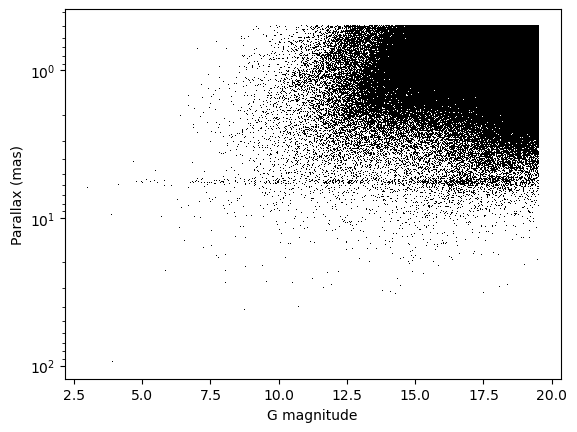

In [15]:
fig, ax = plt.subplots()
ax.semilogy(AP['phot_g_mean_mag'], AP['parallax'], ',k') # , . o
ax.set_xlabel('G magnitude')
ax.set_ylabel('Parallax (mas)')
ax.invert_yaxis()


### other characterizations 

use math operations in pandas

In [18]:
# Nearest star
dmin = 1000. / AP['parallax'].max()
print('smallest distance %.2f pc' % dmin)
# Most distant star in this collection
dmax = 1000. / AP['parallax'].min()
print('smallest distance %.2f pc' % dmax)

smallest distance 10.58 pc
smallest distance 2000.00 pc


In [19]:
### Compute a new data series with distance in parsec

AP['distance'] = 1000.0 / AP['parallax']
AP.head()

,Unnamed: 0,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,radial_velocity,phot_variable_flag,has_rvs,has_epoch_rv,distance
0,5,245239819399673600,56.063158,46.325768,0.664583,0.237738,-1.988098,0.322328,-1.490062,0.208948,18.654490,1.997845,NaN,NOT_AVAILABLE,False,False,1504.704012
1,13,245239819403917440,56.054993,46.325389,0.519589,0.046450,-0.565107,0.047165,-1.564186,0.039426,16.045202,1.352949,NaN,NOT_AVAILABLE,False,False,1924.596292
2,15,245239819403919104,56.047806,46.323467,0.668110,0.056565,-0.555729,0.053444,-4.852082,0.046857,16.300074,1.426871,NaN,NOT_AVAILABLE,False,False,1496.759958
3,19,245239853763644800,56.069544,46.344032,0.926546,0.050401,1.831877,0.052052,-4.761006,0.043049,16.114220,1.330409,NaN,NOT_AVAILABLE,False,False,1079.276925
4,23,245239952542433152,56.087521,46.344403,0.531419,0.128192,0.374183,0.155711,-0.886560,0.116613,18.011433,1.400435,NaN,NOT_AVAILABLE,False,False,1881.754080


### plot distances
show the other way to address a dat series

Text(0, 0.5, 'Parallax (mas)')

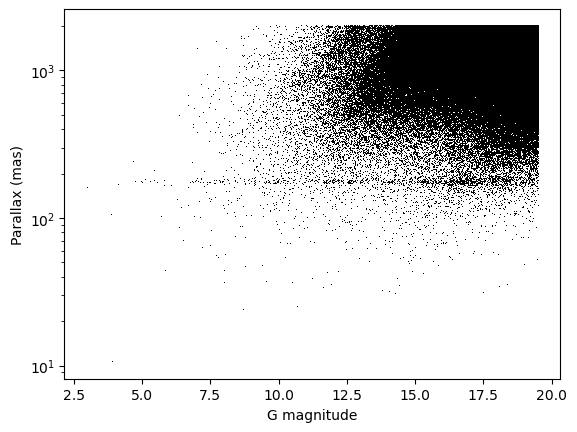

In [23]:
fig, ax = plt.subplots()
ax.semilogy(AP.phot_g_mean_mag, AP.distance , ',k') # , . o
ax.set_xlabel('G magnitude')
ax.set_ylabel('Parallax (mas)')



Text(0, 0.5, 'Parallax (mas)')

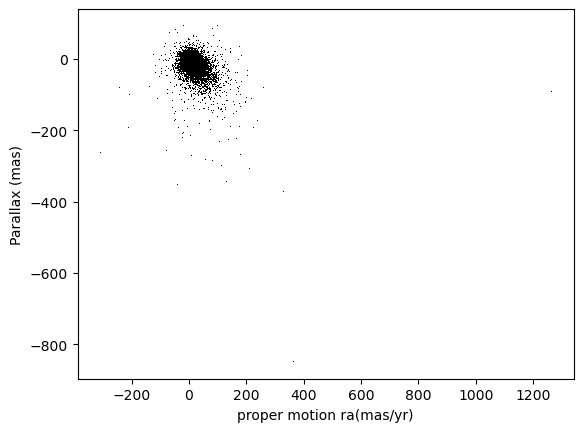

In [26]:
# proper motions
fig, ax = plt.subplots()
ax.plot(AP.pmra, AP.pmdec, ',k')
ax.set_xlabel('proper motion ra(mas/yr)')
ax.set_ylabel('')

(7.9289999999999985, 37.929)

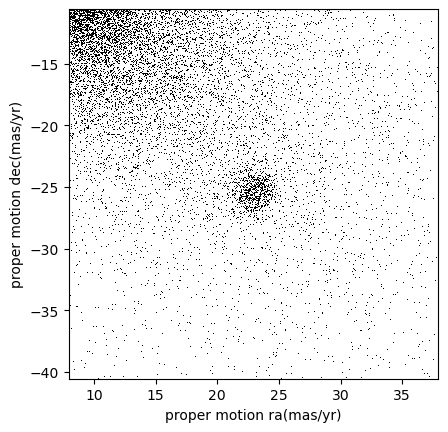

In [29]:
pmra_ap,pmdec_ap = 22.929, -25.556
delta =15. # half width of plot
#define plot limits
xmin, xmax = pmra_ap - delta, pmra_ap + delta
ymin, ymax = pmdec_ap -delta, pmdec_ap + delta
fig, ax = plt.subplots()
ax.plot(AP.pmra, AP.pmdec, ',k')
ax.set_xlabel('proper motion ra(mas/yr)')
ax.set_ylabel('proper motion dec(mas/yr)')
ax.set_aspect('equal')
ax.set_ylim(ymin,ymax)
ax.set_xlim(xmin,xmax)

In [30]:
Subset = AP[(AP.distance <200)& (AP.distance >150)]
print(len(Subset))

1780
